---

# **Fundamentals of Data Science**
## Week 13: Model Evaluation & Decision Making

---

# Table of Contents
1. Learning Objectives
2. Context & Motivation
3. Model Evaluation ในงานประเภทต่างๆ
   - Classification
   - Regression
   - Clustering
4. Deliverable Checklist

# 1) Learning Objectives

เมื่อจบคาบนี้ นักศึกษาจะสามารถ

1. อธิบายความแตกต่างของ Model Evaluation แบบต่างๆ ได้
2. เปรียบเทียบข้อดี ข้อจำกัด และบริบทการเลือกใช้ metrics แต่ละชนิดได้อย่างมีเหตุผล

# 2) Context & Motivation

ใน Week 12 เราสร้างโมเดล  
คำถามของ Week 13 คือ:

> “โมเดลนี้ดีแค่ไหน — และดีในความหมายแบบไหน?”

คำว่า “ดี” ไม่ได้มีความหมายเดียว

- Regression → error ต้องต่ำ
- Classification → ต้องดู precision/recall
- Clustering → ไม่มี ground truth

การใช้ metric ผิดประเภท  
อาจทำให้ “สรุปผิด” ทั้งงาน

# 3) Model Evaluation ในงานประเภทต่างๆ

 ## 3.1 Classification

### 3.1.1 Confusion Matrix

ตารางที่ใช้ในการแสดงผลการทำงานของโมเดลในการจำแนกประเภท (classification) โดยแสดงค่าทั้งหมดของ True Positives (TP), True Negatives (TN), False Positives (FP) และ False Negatives (FN)

**โครงสร้างของ Confusion Matrix**:
```
                Predicted Negative   Predicted Positive
Actual Negative         TN                   FP
Actual Positive         FN                   TP
```

**การแปลความหมาย**:
- **True Positives (TP)**: จำนวนการทำนายที่ถูกต้องว่าเป็นค่าบวก (Positive)
- **True Negatives (TN)**: จำนวนการทำนายที่ถูกต้องว่าเป็นค่าลบ (Negative)
- **False Positives (FP)**: จำนวนการทำนายที่ผิดว่าเป็นค่าบวก (Positive)
- **False Negatives (FN)**: จำนวนการทำนายที่ผิดว่าเป็นค่าลบ (Negative)

#### การใช้งานใน `sklearn`

In [ ]:
y_true = [0, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1]

from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, y_pred)

array([[2, 0],
       [1, 2]])

### 3.1.2 Accuracy

ความแม่นยำในการทำนาย หรือสัดส่วนของการทำนายที่ถูกต้อง

**สูตรการคำนวณ**:

$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_true, y_pred)

0.8

### 3.1.3 Precision

ความแม่นยำในการทำนายค่าบวก (ความสามารถในการทำนายค่า Positive ที่ถูกต้อง)

**สูตรการคำนวณ**:

$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import precision_score

precision_score(y_true, y_pred)

1.0

### 3.1.4 Recall (Sensitivity)

ความไวในการทำนายค่าบวก (ความสามารถในการทำนายค่า True Positive)

**สูตรการคำนวณ**:

$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_true, y_pred)

0.6666666666666666

### 3.1.5 F1 Score

ค่าเฉลี่ยถ่วงน้ำหนักของ Recall และ Precision

**สูตรการคำนวณ**:

$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_true, y_pred)

0.8

### 3.1.6 AUC (Area Under the ROC Curve)

พื้นที่ใต้กราฟ ROC ใช้วัดประสิทธิภาพของโมเดลในการแยกแยะระหว่างคลาส

<center>
  <img src="https://i2.wp.com/sefiks.com/wp-content/uploads/2020/12/roc-curve-original.png"><br>
  imgae from: <a href="https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg">https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg</a>
</center>

- **ROC** - **R**eceiver **O**perating **C**haracteristic
- **AUC** - **A**rea **U**nder the **C**urve

#### การใช้งานใน `sklearn`

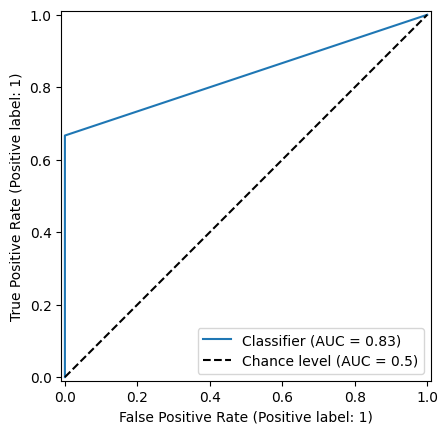

In [ ]:
from sklearn.metrics import RocCurveDisplay

_ = RocCurveDisplay.from_predictions(y_true, y_pred, plot_chance_level=True)

### 3.1.7 Kappa (Cohen's Kappa)

**ปัญหา: Accuracy หลอกได้**

สมมติข้อมูล 100 ตัวอย่าง:

* 90 ตัวเป็น Class A
* 10 ตัวเป็น Class B

โมเดลทายทุกตัวเป็น A → Accuracy = 90%

แต่โมเดลไม่ได้เรียนรู้อะไรเลย

เราต้องการ metric ที่ถามว่า:

> โมเดล “ดีกว่าการเดาแบบสุ่มตามสัดส่วนข้อมูล” แค่ไหน?

Kappa วัด:

> ระดับความสอดคล้อง (agreement)  
> หลังจากหัก “ความสอดคล้องที่เกิดขึ้นโดยบังเอิญ” ออกแล้ว

**สูตรการคำนวณ**:

$Kappa = \frac{P_o - P_e}{1 - P_e}$

- $P_o$: สัดส่วนความแม่นยำที่เกิดขึ้นจริง (observed accuracy)
- $P_e$: สัดส่วนความแม่นยำที่เกิดขึ้นแบบสุ่ม (expected accuracy)

#### คิดทีละขั้นจาก Confusion Matrix

สมมติ binary classification:

|        | Pred A | Pred B | Total |
| ------ | ------ | ------ | ----- |
| True A | 50     | 10     | 60    |
| True B | 5      | 35     | 40    |
| Total  | 55     | 45     | 100   |

#### Step 1: คำนวณ Observed Agreement (Po)

$
P_o = \frac{50 + 35}{100} = 0.85
$

Accuracy = 85%

#### Step 2: คำนวณ Expected Agreement (Pe)

คำนวณจาก distribution ของ row และ column

$
P_e = \left(\frac{60}{100} \times \frac{55}{100}\right)
* \left(\frac{40}{100} \times \frac{45}{100}\right)
$

$
P_e = (0.6 \times 0.55) + (0.4 \times 0.45)
$

$
P_e = 0.33 + 0.18 = 0.51
$

#### Step 3: คำนวณ Kappa

$
\kappa = \frac{0.85 - 0.51}{1 - 0.51}
$

$
\kappa = \frac{0.34}{0.49} = 0.694
$

#### การตีความค่า Kappa

ช่วงค่า:

* κ = 1 → agreement สมบูรณ์
* κ = 0 → ไม่ดีกว่าสุ่ม
* κ < 0 → แย่กว่าสุ่ม

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import cohen_kappa_score

cohen_kappa_score(y_true, y_pred)

np.float64(0.6153846153846154)

### 3.1.8 MCC (Matthews Correlation Coefficient)

การวัดประสิทธิภาพของโมเดลโดยพิจารณาความสัมพันธ์ระหว่างค่าทำนายและค่าจริง

**สูตรการคำนวณ**:

$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$

#### ช่วงค่าและการตีความ

MCC มีช่วง:

* **+1** = ทายถูกสมบูรณ์
* **0** = ไม่ดีกว่าสุ่ม (ในเชิงความสัมพันธ์)
* **-1** = ทาย “กลับกันหมด” (ตรงข้ามสมบูรณ์)

#### ตัวอย่างกรณี A: Accuracy สูงเพราะทายตาม majority

สมมติ N=100, positive มี 10, negative มี 90
โมเดลทายทุกตัวเป็น negative

* TP=0
* TN=90
* FP=0
* FN=10

Accuracy = (TP+TN)/100 = 90% (ดูดี!)

คำนวณ MCC:

$
MCC=\frac{0\cdot 90 - 0\cdot 10}{\sqrt{(0+0)(0+10)(90+0)(90+10)}}
$

จะเจอปัญหา **ตัวส่วนเป็น 0** (เพราะ (TP+FP)=0)  
ซึ่งในทางปฏิบัติ MCC จะถือว่า **นิยามไม่ได้ / ให้ 0** (library ส่วนมากคืน 0)  
แปลว่า “โมเดลนี้ไม่มีความสามารถแยกคลาสจริง ๆ”

**นี่คือคุณค่าของ MCC:** มันไม่ยอมให้โมเดล “หลอก” ด้วย accuracy

#### ตัวอย่างกรณี B: โมเดลพอแยกได้จริง (ยัง imbalance)

สมมติ:

* TP=6
* FN=4  (จริงบวก 10)
* FP=8
* TN=82 (จริงลบ 90)

Accuracy = (6+82)/100 = 88%

คำนวณ MCC:

ส่วนบน:
$
TP\cdot TN - FP\cdot FN = 6\cdot82 - 8\cdot4 = 492 - 32 = 460
$

ส่วนล่าง:
$
\sqrt{(6+8)(6+4)(82+8)(82+4)}
= \sqrt{14\cdot10\cdot90\cdot86}
$

$
14\cdot10=140,\quad 90\cdot86=7740,\quad 140\cdot7740=1,083,600
$

$
\sqrt{1,083,600}\approx 1041.9
$

ดังนั้น
$
MCC \approx 460/1041.9 \approx 0.44
$

ตีความ: โมเดลเริ่มมี “สัญญาณ” จริง แต่ยังไม่ดีมาก (moderate)

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import matthews_corrcoef

matthews_corrcoef(y_true, y_pred)

np.float64(0.6666666666666666)

### 3.1.9 Classification Report

รายงานที่รวมค่าเมตริกต่างๆ เช่น Precision, Recall, F1-score, และ Support สำหรับแต่ละคลาส โดยจะช่วยให้สามารถประเมินประสิทธิภาพของโมเดลการจำแนกประเภทได้อย่างละเอียด

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



### Exercise 1

ใช้ชุดข้อมูล [iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris) ทำ classification (ด้วยวิธีใดก็ได้) แล้ววัดค่า metrics ที่ได้

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print("Accuracy", accuracy_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred, average="macro"))
print("Recall", recall_score(y_test, y_pred, average="macro"))
print("F1-score", f1_score(y_test, y_pred, average="macro"))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy 1.0
Precision 1.0
Recall 1.0
F1-score 1.0


[[10  0  0]

 [ 0  9  0]

 [ 0  0 11]]

 คือ คลาส 1 iris classification ถูก 10 ตัว, คลาส 2 ถูก 9 ตัว, คลาส 3 ถูก 11 ตัว

---

Accuracy 1.0 = ทำนายถูก 100%

Precision 1.0 = ความแม่นยำในการทำนาย ถูกทุกครั้งที่ทดลอง

Recall 1.0 = โมเดลหาเจอหมด

F1-score 1.0 = ค่าเฉลี่ยถ่วงน้ำหนักของ Recall กับ Precision

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## 3.2 Regression

### 3.2.1 Mean Absolute Error (MAE)

ค่าเฉลี่ยของความคลาดเคลื่อนที่เป็นบวกของค่าทำนายกับค่าจริง

**สูตรการคำนวณ**:

$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

#### การใช้งานใน `sklearn`

In [ ]:
y_true = [3, 0, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_true, y_pred)

0.375

### 3.2.2 Mean Squared Error (MSE)

ค่าเฉลี่ยของค่าผลต่างระหว่างค่าทำนายกับค่าจริงยกกำลังสอง

**สูตรการคำนวณ**:

$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true, y_pred)

0.3125

### 3.2.3 Root Mean Squared Error (RMSE)

รากที่สองของค่าเฉลี่ยของค่าผลต่างระหว่างค่าทำนายกับค่าจริงยกกำลังสอง

**สูตรการคำนวณ**:

$\text{RMSE} = \sqrt{\text{MSE}}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_true, y_pred)

0.5590169943749475

### 3.2.4 R-squared ($R^2$)

สัดส่วนของความแปรปรวนในค่าตอบสนองที่สามารถอธิบายได้ด้วยตัวแบบการถดถอย

**สูตรการคำนวณ**:

$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import r2_score

r2_score(y_true, y_pred)

0.9519230769230769

### 3.2.5 Root Mean Squared Logarithmic Error (RMSLE)

รากที่สองของค่าเฉลี่ยของค่าผลต่างระหว่างลอการิทึมของค่าทำนายและค่าจริงยกกำลังสอง

**สูตรการคำนวณ**:

$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(1 + y_i) - \log(1 + \hat{y}_i))^2}$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import root_mean_squared_log_error

root_mean_squared_log_error(y_true, y_pred)

0.08902735015807975

### 3.2.6 Mean Absolute Percentage Error (MAPE)

ค่าเฉลี่ยของค่าผลต่างสัมบูรณ์ระหว่างค่าทำนายและค่าจริง เมื่อเทียบกับค่าจริงในรูปของเปอร์เซ็นต์

**สูตรการคำนวณ**:

$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%$

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(y_true, y_pred)

0.07738095238095238

### Exercise 2

ใช้ชุดข้อมูล [diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html#sklearn.datasets.load_diabetes) ทำ linear regression แล้ววัดค่า metrics ที่ได้

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
import numpy as np

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred))

MAE 42.79409467959994
MSE 2900.193628493482
RMSE 53.85344583676593
R2 0.4526027629719195


MAE 42.79409467959994 = ค่าเฉลี่ยของความคลาดเคลื่อนที่เป็นบวกของค่าทำนายกับค่าจริง

MSE 2900.193628493482 = ค่าเฉลี่ยของ(ค่าผลต่างระหว่างค่าทำนายกับค่าจริง)^2

RMSE 53.85344583676593 = √MSE

R2 0.4526027629719195 = สัดส่วนของความแปรปรวนในค่าตอบสนอง

## 3.3 Clustering

### 3.3.1 Silhouette Score

การวัดความคล้ายคลึงกันของตัวอย่างในกลุ่มของตัวอย่างเดียวกัน (cohesion) โดยเปรียบเทียบกับตัวอย่างในกลุ่มอื่น (separation)

**สูตรการคำนวณ**:

$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$

- $a(i)$: ค่าเฉลี่ยของระยะทางระหว่างตัวอย่าง $i$ และตัวอย่างอื่น ๆ ในกลุ่มเดียวกัน
- $b(i)$: ค่าเฉลี่ยของระยะทางระหว่างตัวอย่าง $i$ และตัวอย่างอื่น ๆ ในกลุ่มที่ใกล้ที่สุด

**การตีความ**:

ค่า Silhouette อยู่ในช่วง -1 ถึง 1 โดยค่าสูงแสดงถึงการจัดกลุ่มที่ดี
- **ค่าใกล้ 1**: หมายถึงตัวอย่างนั้นอยู่ในกลุ่มที่ถูกต้องและกลุ่มนั้นมีความแตกต่างจากกลุ่มอื่นอย่างชัดเจน
- **ค่าใกล้ 0**: หมายถึงตัวอย่างอยู่ในเส้นแบ่งระหว่างสองกลุ่ม
- **ค่าติดลบ**: หมายถึงตัวอย่างนั้นอาจถูกจัดอยู่ในกลุ่มที่ไม่ถูกต้อง

#### การใช้งานใน `sklearn`

In [ ]:
X = [[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]]
labels = [0, 0, 0, 1, 1, 1]

from sklearn.metrics import silhouette_score

silhouette_score(X, labels)

np.float64(0.2871407974806454)

### 3.3.2 Calinski-Harabasz Index

การวัดความสัมพันธ์ระหว่างความแปรปรวนระหว่างกลุ่มกับความแปรปรวนภายในกลุ่ม

**สูตรการคำนวณ**:

$\text{Calinski-Harabasz Index} = \frac{\text{Tr}(B_k) / (k - 1)}{\text{Tr}(W_k) / (n - k)}$

- $\text{Tr}(B_k)$: Trace ของเมทริกซ์ความแปรปรวนระหว่างกลุ่ม
- $\text{Tr}(W_k)$: Trace ของเมทริกซ์ความแปรปรวนภายในกลุ่ม
- $k$: จำนวนกลุ่ม
- $n$: จำนวนตัวอย่าง

**การตีความ**:

ค่ายิ่งสูงแสดงถึงการจัดกลุ่มที่ดีและชัดเจน

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import calinski_harabasz_score

calinski_harabasz_score(X, labels)

np.float64(3.375)

### 3.3.3 Davies-Bouldin Index

การวัดความคล้ายคลึงระหว่างกลุ่ม ซึ่งค่า Davies-Bouldin ที่ต่ำกว่าแสดงถึงการแบ่งกลุ่มที่ดีกว่า

**สูตรการคำนวณ**:

$\text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{d_i + d_j}{d_{ij}} \right)$

- $d_i$: ค่าเฉลี่ยของระยะทางระหว่างตัวอย่างในกลุ่ม $i$
- $d_{ij}$: ระยะทางระหว่างจุดศูนย์กลางของกลุ่ม $i$ และ $j$
- $k$: จำนวนกลุ่ม

#### การใช้งานใน `sklearn`

In [ ]:
from sklearn.metrics import davies_bouldin_score

davies_bouldin_score(X, labels)

np.float64(0.8888888888888888)

## Exercise 3

ใช้ชุดข้อมูล [wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine) ทำ clustering (ด้วยวิธีใดก็ได้) แล้ววัดค่า metrics ที่ได้

In [ ]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = load_wine(return_X_y=True)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

In [ ]:
score = silhouette_score(X, labels)
print("Silhouette Score", score)

Silhouette Score 0.5595823478987213


Silhouette Score 0.5595823478987213 = คุณภาพของการจัดกลุ่มตัวอย่าง


# 4) Deliverables for This Week

* [ ] Exercise ครบทุกอัน